## Load Library

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import signal, stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary
from torch.autograd import Function
from torch.optim.lr_scheduler import ExponentialLR

import time
import pickle
from sklearn.metrics import r2_score
import math
from sklearn.manifold import TSNE
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="networkx.utils.backends")

## Training parameters

In [2]:
class params:
    model_num = 8
    save_every = 100
    lr = 0.0009
    epochs = 100
    lr_decay = 0.9
    exp_copy_time = 37
    batch_size_source = 5
    batch_size_target = 5
    alpha_high_value = 1.0
    alpha_low_value = 0.0
    alpha_decay = 10
    num_samples = 6560    # Keep simulated data, resample experimental data
    duration = 15.47

## Load and processing data

### Simulated data

In [3]:
# Load cvs file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Single_Layer'
fname = os.path.join(data_dir, '1_layer_SimData_1547.csv')
SimData = pd.read_csv(fname).to_numpy()

In [4]:
# Seperate data and label
Sim_Data = SimData[:,3:]    
Sim_Label = SimData[:,0:3]

SimTime = np.arange(15.47/6560,15.47+15.47/6560,15.47/6560)[:-1] # Total time is 15.47 ns

SimTrain_Data = Sim_Data
SimTrain_Label = Sim_Label

In [5]:
# Check data size
print(SimTrain_Data.shape)
print(SimTrain_Label.shape)

(16500, 6560)
(16500, 3)


### Experimental data

In [6]:
fname = os.path.join(data_dir, '1_layer_TEST_ExpData.xlsx')
ExpTest = pd.read_excel(fname)

# Time
ExpTest_Time_1 = np.tile(ExpTest.iloc[2, 4:514].to_numpy(), (25,1))
ExpTest_Time_2 = np.tile(ExpTest.iloc[33, 4:514].to_numpy(), (25,1))
ExpTest_Time_3 = np.tile(ExpTest.iloc[65, 4:514].to_numpy(), (25,1))
ExpTest_Time_4 = np.tile(ExpTest.iloc[97, 4:514].to_numpy(), (25,1))
ExpTest_Time_5 = np.tile(ExpTest.iloc[129, 4:514].to_numpy(), (25,1))
ExpTest_Time_6 = np.tile(ExpTest.iloc[162, 4:514].to_numpy(), (25,1))
ExpTest_Time = np.concatenate((ExpTest_Time_1, ExpTest_Time_2, ExpTest_Time_3, ExpTest_Time_4,
                               ExpTest_Time_5, ExpTest_Time_6), axis=0)

# Label
ExpTest_Label_1 = ExpTest.iloc[3:28, 0:3].to_numpy()
ExpTest_Label_2 = ExpTest.iloc[34:59, 0:3].to_numpy()
ExpTest_Label_3 = ExpTest.iloc[66:91, 0:3].to_numpy()
ExpTest_Label_4 = ExpTest.iloc[98:123, 0:3].to_numpy()
ExpTest_Label_5 = ExpTest.iloc[130:155, 0:3].to_numpy()
ExpTest_Label_6 = ExpTest.iloc[163:188, 0:3].to_numpy()
ExpTest_Label = np.concatenate((ExpTest_Label_1, ExpTest_Label_2, ExpTest_Label_3, ExpTest_Label_4, 
                                ExpTest_Label_5, ExpTest_Label_6), axis=0)

# Data
ExpTest_Data_1 = ExpTest.iloc[3:28, 4:514].to_numpy()
ExpTest_Data_2 = ExpTest.iloc[34:59, 4:514].to_numpy()
ExpTest_Data_3 = ExpTest.iloc[66:91, 4:514].to_numpy()
ExpTest_Data_4 = ExpTest.iloc[98:123, 4:514].to_numpy()
ExpTest_Data_5 = ExpTest.iloc[130:155, 4:514].to_numpy()
ExpTest_Data_6 = ExpTest.iloc[163:188, 4:514].to_numpy()
ExpTest_Data = np.concatenate((ExpTest_Data_1, ExpTest_Data_2, ExpTest_Data_3, ExpTest_Data_4, 
                               ExpTest_Data_5, ExpTest_Data_6), axis=0)

In [7]:
# Check data size
print(ExpTest_Label.shape)
print(ExpTest_Data.shape)

(150, 3)
(150, 510)


### Processing dataset

In [8]:
# Process the signal to ensure a consistent duration and number of samples
def signal_processing(input_signal, time, duration, num_samples):
    idx = (np.abs(time - duration)).argmin()                       # Find the index corresponding to the specified duration
    truncate_siganl = input_signal[0:idx]                          # Truncate the signal to the specified duration
    output_signal = signal.resample(truncate_siganl, num_samples)  # Generate the signal with the specified number of samples
    return output_signal

# Normalize the signal using min-max normalization
def norm(input_signal):
    input_signal = input_signal/np.max(input_signal)
    return input_signal

# Shift signal to ensure the same start time in both simulated and experimental signals
def signal_shifting(sim_signal, exp_signal, sim_time, exp_time):
    sim_max_index = np.argmax(sim_signal)       # Find the index of the maximum value of simulated signal
    sim_max_time = sim_time[sim_max_index]      # Find the time of the maximum value of simulated signal
    exp_max_index = np.argmax(exp_signal)       # Find the index of the maximum value of experimental signal
    exp_max_time = exp_time[exp_max_index]      # Find the time of the maximum value of experimental signal
    time_diff = exp_max_time-sim_max_time       # Calcualte the time difference between simulated and experimental signals
    shift_index = np.absolute(exp_time-time_diff).argmin()    # Find the index of where the experimental signal should start
    exp_signal_shift = exp_signal[shift_index:]               # Remove the samples at the begining of the experimental signal
    exp_time_shift = exp_time[:len(exp_time)-shift_index]     # Update the time vector of the experimental signal
    return exp_signal_shift, exp_time_shift

In [9]:
unified_time = np.arange(params.duration/params.num_samples,params.duration+params.duration/params.num_samples,params.duration/params.num_samples)[:-1]
ExpTest_Data_Pro = np.zeros((ExpTest_Data.shape[0],params.num_samples))
SimTrain_Data_Pro = SimTrain_Data    # Simulated data already normalized

# Keep simulated data, upsample experimental data
for i in range(ExpTest_Data.shape[0]):
    exp_signal_shift, exp_time_shift = signal_shifting(SimTrain_Data[0], ExpTest_Data[i], SimTime, ExpTest_Time[i])
    ExpTest_Data_Pro[i] = norm(signal_processing(exp_signal_shift, exp_time_shift, params.duration, params.num_samples))

In [10]:
# Normalize the training labels
SimTrain_Label_Pro = np.zeros((SimTrain_Label.shape))

for i in range(SimTrain_Label.shape[1]):
    SimTrain_Label_Pro[:,i] = (SimTrain_Label[:,i] - np.min(SimTrain_Label[:,i])) /\
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i]))

In [11]:
# Check data size
print(ExpTest_Data_Pro.shape)

(150, 6560)


### Build data loader

In [12]:
# Source loader
SimTrain_Data_Pro_Tensor = torch.tensor(SimTrain_Data_Pro, dtype=torch.float32)
SimTrain_Label_Pro_Tensor = torch.tensor(SimTrain_Label_Pro, dtype=torch.float32)
Source_Dataset = TensorDataset(SimTrain_Data_Pro_Tensor,SimTrain_Label_Pro_Tensor)
source_loader = DataLoader(Source_Dataset, params.batch_size_source, shuffle=True)

# Target loader
ExpTest_Data_Pro_Tensor = torch.tensor(np.tile(ExpTest_Data_Pro, (params.exp_copy_time, 1)), dtype=torch.float32)
ExpTest_Label_Tensor = torch.tensor(np.tile(ExpTest_Label, (params.exp_copy_time, 1)).astype(np.float32), dtype=torch.float32)
Target_Dataset = TensorDataset(ExpTest_Data_Pro_Tensor[:SimTrain_Data.shape[0]],ExpTest_Label_Tensor[:SimTrain_Data.shape[0]])
target_loader = DataLoader(Target_Dataset, params.batch_size_target, shuffle=True)

## Build regression model

In [13]:
class Extractor(nn.Module):
    def __init__(self):
        super(Extractor, self).__init__()
        self.Extractor = nn.Sequential(
            
            # input shape: 1 x 6560
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=5, bias=False),
            # output shape: 32 x 1312
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=5, bias=False),
            # output shape: 64 x 262
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=4, stride=4, bias=False),
            # output shape: 128 x 65
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=4, stride=4, bias=False),
            # output shape: 256 x 16
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1, inplace=True))

    def forward(self, x):
        return self.Extractor(x)
    
class Regressor(nn.Module):
    def __init__(self):
        super(Regressor, self).__init__()
        self.Regressor = nn.Sequential(
            
            # input shape: 256 x 16
            nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=3, bias=False),
            # output shape: 512 x 5
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=512, out_channels=10240, kernel_size=3, stride=3, bias=False),
            # output shape: 10240 x 1
            nn.BatchNorm1d(10240),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Flatten(),
            nn.Linear(10240, 3))

    def forward(self, x):
        x = self.Regressor(x)
        return x
    
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.Discriminator = nn.Sequential(
            
            # input shape: 256 x 16
            nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=3, bias=False),
            # output shape: 512 x 5
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=512, out_channels=1024, kernel_size=3, stride=3, bias=False),
            # output shape: 1024 x 1
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Flatten(),
            nn.Linear(1024, 2))

    def forward(self, input_feature, alpha):
        reversed_input = ReverseLayerF.apply(input_feature, alpha)
        x = self.Discriminator(reversed_input)
        return x

In [14]:
extractor = Extractor().cuda()
summary(extractor, (1,params.num_samples))

regressor = Regressor().cuda()
summary(regressor, (256,15))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1             [-1, 32, 1312]             160
       BatchNorm1d-2             [-1, 32, 1312]              64
         LeakyReLU-3             [-1, 32, 1312]               0
            Conv1d-4              [-1, 64, 262]          10,240
       BatchNorm1d-5              [-1, 64, 262]             128
         LeakyReLU-6              [-1, 64, 262]               0
            Conv1d-7              [-1, 128, 65]          32,768
       BatchNorm1d-8              [-1, 128, 65]             256
         LeakyReLU-9              [-1, 128, 65]               0
           Conv1d-10              [-1, 256, 16]         131,072
      BatchNorm1d-11              [-1, 256, 16]             512
        LeakyReLU-12              [-1, 256, 16]               0
Total params: 175,200
Trainable params: 175,200
Non-trainable params: 0
-------------------------------

## Utility functions

In [15]:
class ReverseLayerF(Function):

    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha

        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        output = grad_output.neg() * ctx.alpha

        return output, None

def _save_checkpoint(epoch,extractor,regressor,discriminator,hist):
    ext_dict = extractor.state_dict()
    reg_dict = regressor.state_dict()
    dis_dict = discriminator.state_dict()
    ext_path = f'./Saved_Model/DANN_Model_{params.model_num}/extractor_checkpoint_{epoch+1}.pt'
    reg_path = f'./Saved_Model/DANN_Model_{params.model_num}/regressor_checkpoint_{epoch+1}.pt'
    dis_path = f'./Saved_Model/DANN_Model_{params.model_num}/discriminator_checkpoint_{epoch+1}.pt'
    torch.save(ext_dict, ext_path)
    torch.save(reg_dict, reg_path)
    torch.save(dis_dict, dis_path)
    with open(f'./Saved_Model/DANN_Model_{params.model_num}/trainHistoryDict_{epoch+1}', 'wb') as file_pi:
            pickle.dump(hist, file_pi)
    print(f'Epoch {epoch+1} | Training checkpoint saved')

## DANN module

In [16]:
def dann(extractor, regressor, discriminator, source_loader, target_loader):
    print("DANN training")
    
    lr_hist = []
    alpha_hist = []
    regression_loss_hist = []
    domain_loss_hist = []
    sample_num = []
    
    # Define parameter groups 
    param_groups = [{"params":extractor.parameters()},
                    {"params":regressor.parameters()},
                    {"params":discriminator.parameters()}]
    
    # Implement stochastic gradient descent
    optimizer = optim.Adam(param_groups, lr=params.lr)
    # optimizer = optim.SGD(param_groups, lr=params.lr, momentum=0.9)
    
    # Decay the learning rate of each parameter group by gamma every epoch
    scheduler = ExponentialLR(optimizer, gamma=params.lr_decay)
    
    # Define loss functions for regressor and discriminator
    regressor_criterion = nn.MSELoss().cuda()
    discriminator_criterion = nn.CrossEntropyLoss().cuda()
    
    for epoch in range(params.epochs):
        print('Epoch : {}'.format(epoch+1))
        regression_loss_epoch = 0.0
        domain_loss_epoch = 0.0
        
        # Indicate the training progress based on 
        # the current number of batches versus the total number of batches
        start_steps = epoch * len(source_loader) # len(DataLoader) = number of batches
        total_steps = params.epochs * len(target_loader)
        
        for batch_idx, (source_dataset, target_dataset) in enumerate(zip(source_loader, target_loader)):
            
            # Seperate data and label
            source_data, source_label = source_dataset
            target_data, target_label = target_dataset
            
            # Send data and label to GPU
            source_data, source_label = torch.unsqueeze(source_data,1).cuda(), source_label.cuda()
            target_data, target_label = torch.unsqueeze(target_data,1).cuda(), target_label.cuda()
            
            # Combine source and target data for discriminator
            combined_data = torch.cat((source_data, target_data), 0)
            
            # Extract features using encoder
            combined_feature = extractor(combined_data)
            source_feature = extractor(source_data)

            # 1. Calculate the regression loss
            regression_pred = regressor(source_feature)
            regression_loss = regressor_criterion(regression_pred, source_label)

            # Determine the hyperparamater alpha in discriminator
            p = float(batch_idx + start_steps) / total_steps
            alpha = float(2.0 * (params.alpha_high_value - params.alpha_low_value) / (1.0 + np.exp(-params.alpha_decay * p)) \
                            - (params.alpha_high_value - params.alpha_low_value) + params.alpha_low_value)
            alpha_hist.append(alpha)
            
            # Prepare domain labels for source and target data
            domain_source_labels = torch.zeros(source_label.shape[0]).type(torch.LongTensor)
            domain_target_labels = torch.ones(target_label.shape[0]).type(torch.LongTensor)
            domain_combined_label = torch.cat((domain_source_labels, domain_target_labels), 0).cuda()
            
            # 2. Calcualte the domain loss
            domain_pred = discriminator(combined_feature, alpha)
            domain_loss = discriminator_criterion(domain_pred, domain_combined_label)
            
            # Sum up the regression loss and the domain loss
            total_loss = regression_loss + domain_loss
            # Sum up the losses within a epoch
            regression_loss_epoch += regression_loss.item()
            domain_loss_epoch += domain_loss.item()
            
            # Resets the gradients
            optimizer.zero_grad()
            # Backward + optimize
            total_loss.backward()
            optimizer.step()
            
        # Print the training metrics
        print('Regression Loss: {:.6f}\tDomain Loss: {:.6f}'.format(regression_loss_epoch/len(target_loader), 
                                                                    domain_loss_epoch/len(target_loader)))
        
        # Record the losses for each epoch
        regression_loss_hist.append(regression_loss_epoch)
        domain_loss_hist.append(domain_loss_epoch)
        
        # Update the learning rate
        scheduler.step()
        lr_hist.append(scheduler.get_last_lr())

        # Put the history metrics in a dict
        hist_checkpoint = dict(lr_hist = lr_hist, alpha_hist = alpha_hist, regression_loss_hist = regression_loss_hist, domain_loss_hist = domain_loss_hist)

        if params.save_every is not None and (epoch+1) % params.save_every == 0:
            _save_checkpoint(epoch,extractor,regressor,discriminator,hist_checkpoint)

## Train DANN

In [57]:
def main():

    if torch.cuda.is_available():
        print('Running GPU : {}'.format(torch.cuda.current_device()))
        extractor = Extractor().cuda()
        regressor = Regressor().cuda()
        discriminator = Discriminator().cuda()
        dann(extractor, regressor, discriminator, source_loader, target_loader)

    else:
        print("There is no GPU -_-!")

if __name__ == "__main__":
    start_time = time.time()
    main()
    end_time = time.time()
    print(f"Training time: {(end_time - start_time) / 60:.1f} min")

Running GPU : 0
DANN training
Epoch : 1
Regression Loss: 0.587622	Domain Loss: 0.000579
Epoch : 2
Regression Loss: 0.255523	Domain Loss: 0.000001
Epoch : 3
Regression Loss: 0.129852	Domain Loss: 0.000001
Epoch : 4
Regression Loss: 0.107597	Domain Loss: 0.000000
Epoch : 5
Regression Loss: 0.062348	Domain Loss: 0.000000
Epoch : 6
Regression Loss: 0.050775	Domain Loss: 0.000000
Epoch : 7
Regression Loss: 0.039146	Domain Loss: 0.000000
Epoch : 8
Regression Loss: 0.033186	Domain Loss: 0.000000
Epoch : 9
Regression Loss: 0.027788	Domain Loss: 0.000000
Epoch : 10
Regression Loss: 0.025421	Domain Loss: 0.000000
Epoch : 11
Regression Loss: 0.025373	Domain Loss: 0.000000
Epoch : 12
Regression Loss: 0.020334	Domain Loss: 0.000000
Epoch : 13
Regression Loss: 0.018005	Domain Loss: 0.000000
Epoch : 14
Regression Loss: 0.014720	Domain Loss: 0.000000
Epoch : 15
Regression Loss: 0.013541	Domain Loss: 0.000000
Epoch : 16
Regression Loss: 0.012338	Domain Loss: 0.000000
Epoch : 17
Regression Loss: 0.01208

## Test loss curve

In [17]:
Test_R_all = np.zeros((int(params.epochs/params.save_every),1))

extractor = Extractor()
regressor = Regressor()

for j in range(int(params.epochs/params.save_every)):
    
    # Load trained models
    extractor.load_state_dict(torch.load(f'./Saved_Model/DANN_Model_{params.model_num}/extractor_checkpoint_{(j+1)*100}.pt'))
    regressor.load_state_dict(torch.load(f'./Saved_Model/DANN_Model_{params.model_num}/regressor_checkpoint_{(j+1)*100}.pt'))
    
    # Evaluate using the experimental testing dataset
    extractor.eval()
    regressor.eval()
    
    with torch.no_grad():
        Features_Target = extractor(torch.unsqueeze(torch.tensor(ExpTest_Data_Pro, dtype=torch.float32),1))
        ExpTest_Pred_Pro = regressor(Features_Target)

    # De-normalize the predictions
    ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

    for i in range(ExpTest_Pred_Pro.shape[1]):
        ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
            (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])
    
    # Calculate R
    Test_R_all[j] = np.corrcoef(ExpTest_Label[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]

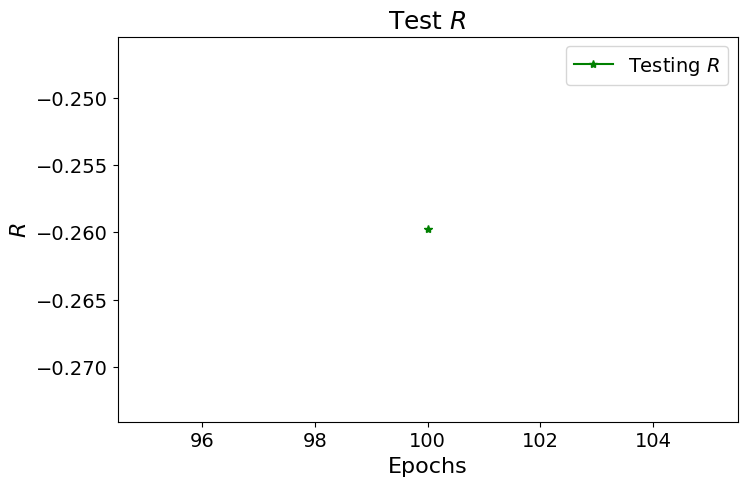

The highest test R is achieved at Epoch: 100


In [18]:
fig = plt.figure(figsize=(8, 5))
plt.plot(range(100,params.epochs+1,100), Test_R_all, 'g-*', label='Testing $R$')
plt.title('Test $R$',fontsize=18)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('$R$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

epoch = int((np.where(Test_R_all == Test_R_all.max())[0][0] + 1) * 100)
print(f'The highest test R is achieved at Epoch: {epoch}')

## Load trained model

In [19]:
select_epochs = 100

In [20]:
# Load trained model
extractor = Extractor()
regressor = Regressor()

extractor.load_state_dict(torch.load(f'./Saved_Model/DANN_Model_{params.model_num}/extractor_checkpoint_{select_epochs}.pt'))
regressor.load_state_dict(torch.load(f'./Saved_Model/DANN_Model_{params.model_num}/regressor_checkpoint_{select_epochs}.pt'))

# Load train history
with open(f'./Saved_Model/DANN_Model_{params.model_num}/trainHistoryDict_{select_epochs}', 'rb') as file_pi:
        saved_history = pickle.load(file_pi)

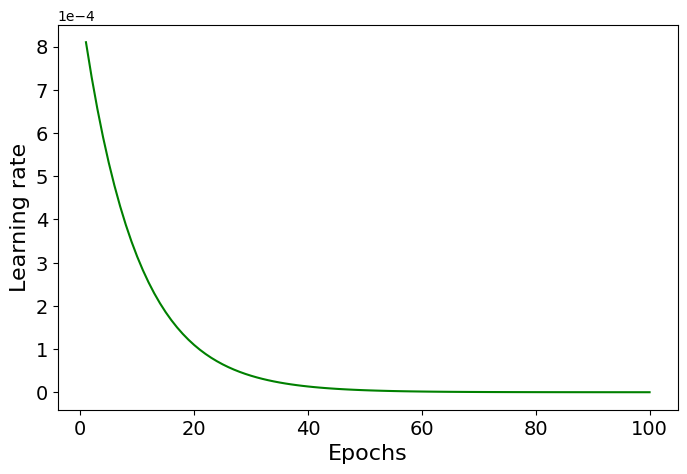

In [21]:
lr_train = torch.tensor(saved_history['lr_hist'])
epochs = range(1,len(lr_train)+1)
fig = plt.figure(figsize=(8, 5))
plt.plot(epochs, lr_train[:,0], 'g')
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Learning rate',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.show()

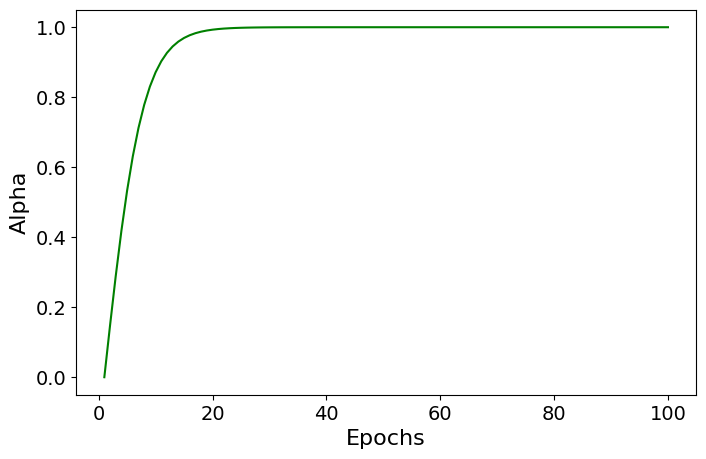

In [22]:
alpha_train = torch.tensor(saved_history['alpha_hist'])
epochs = range(1,len(lr_train)+1)
fig = plt.figure(figsize=(8, 5))
plt.plot(epochs, alpha_train[range(0,len(alpha_train),math.ceil(ExpTest_Label.shape[0]*params.exp_copy_time/params.batch_size_target))], 'g')
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Alpha',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.show()

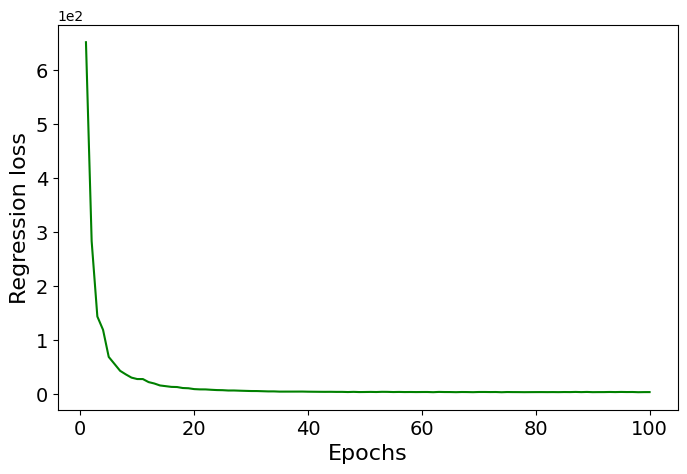

In [23]:
regression_loss_train = torch.tensor(saved_history['regression_loss_hist'])
epochs = range(1,len(lr_train)+1)
fig = plt.figure(figsize=(8, 5))
plt.plot(epochs, regression_loss_train, 'g')
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Regression loss',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.show()

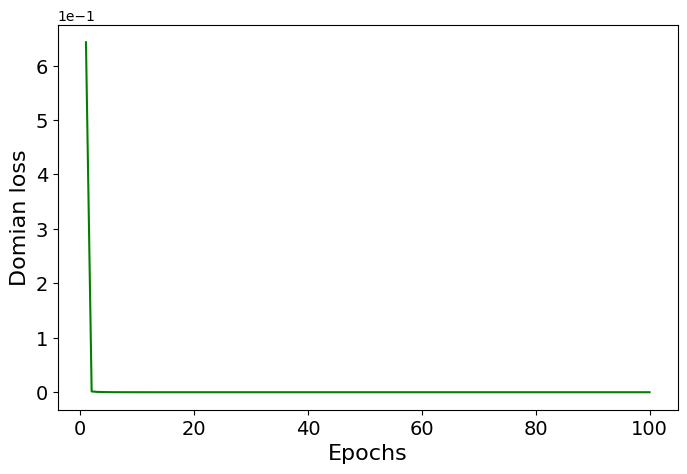

In [24]:
domain_loss_train = torch.tensor(saved_history['domain_loss_hist'])
epochs = range(1,len(lr_train)+1)
fig = plt.figure(figsize=(8, 5))
plt.plot(epochs, domain_loss_train, 'g')
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Domian loss',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.show()

## Evaluate using experimental tesing dataset

In [25]:
# Evaluate using the experimental testing dataset
extractor.eval()
regressor.eval()

with torch.no_grad():
    Features_Target = extractor(torch.unsqueeze(torch.tensor(ExpTest_Data_Pro, dtype=torch.float32),1))
    ExpTest_Pred_Pro = regressor(Features_Target)
    
# De-normalize the predictions
ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

for i in range(ExpTest_Pred_Pro.shape[1]):
    ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred[:,0] - ExpTest_Label[:,0]) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R^2
ExpTest_R2_p1 = r2_score(ExpTest_Label[:,0], ExpTest_Pred[:,0])
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_Label[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred[:,0]) - np.mean(ExpTest_Label[:,0])
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

p1 MSE on experimental tesing dataset: 69.1664512467
p1 R2 on experimental tesing dataset: -5.5947830730
p1 R on experimental tesing dataset: -0.2597707204
p1 Bias on experimental tesing dataset: -6.6331331110


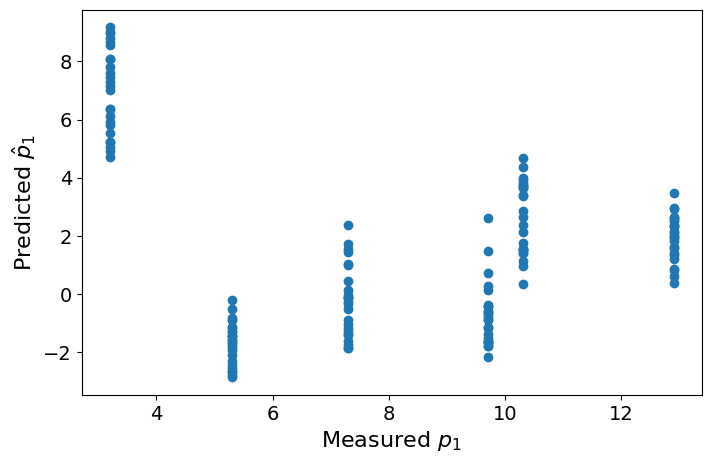

In [26]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,0],ExpTest_Pred[:,0])
plt.xlabel('Measured $p_1$',fontsize=16)
plt.ylabel('Predicted $\hat{p}_1$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [27]:
# Mean square error
ExpTest_MSE_c1 = np.mean((ExpTest_Pred[:,1] - ExpTest_Label[:,1]) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c1))

# R^2
ExpTest_R2_c1 = r2_score(ExpTest_Label[:,1], ExpTest_Pred[:,1])
print('c1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c1))

# R
ExpTest_R_c1 = np.corrcoef(ExpTest_Label[:,1].astype(float), ExpTest_Pred[:,1].astype(float))[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (ExpTest_R_c1))

# Bias
ExpTest_Bias_c1 = np.mean(ExpTest_Pred[:,1]) - np.mean(ExpTest_Label[:,1])
print('c1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c1))

c1 MSE on experimental tesing dataset: 0.0032547815
c1 R2 on experimental tesing dataset: -8.4706210548
c1 R on experimental tesing dataset: -0.1023458856
c1 Bias on experimental tesing dataset: -0.0520642726


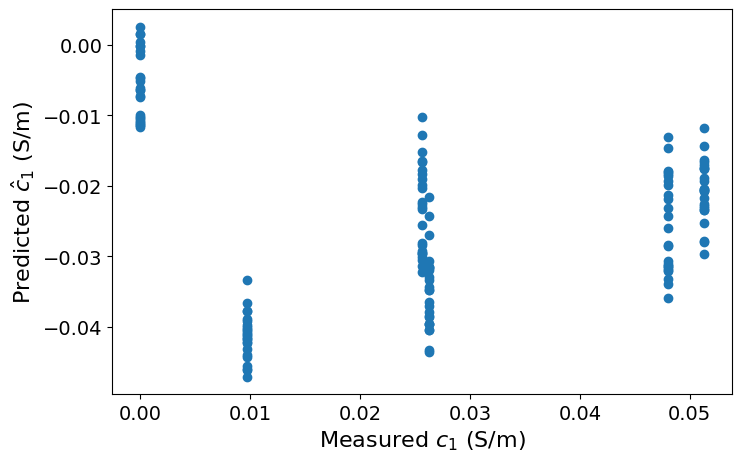

In [28]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,1],ExpTest_Pred[:,1])
plt.xlabel('Measured $c_1$ (S/m)',fontsize=16)
plt.ylabel('Predicted $\hat{c}_1$ (S/m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [29]:
# Mean square error
ExpTest_MSE_d1 = np.mean((ExpTest_Pred[:,2] - ExpTest_Label[:,2]) ** 2)
print('d1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_d1))

# R^2
ExpTest_R2_d1 = r2_score(ExpTest_Label[:,2], ExpTest_Pred[:,2])
print('d1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_d1))

# R
ExpTest_R_d1 = np.corrcoef(ExpTest_Label[:,2].astype(float), ExpTest_Pred[:,2].astype(float))[0,1]
print('d1 R on experimental tesing dataset: %.10f' % (ExpTest_R_d1))

# Bias
ExpTest_Bias_d1 = np.mean(ExpTest_Pred[:,2]) - np.mean(ExpTest_Label[:,2])
print('d1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_d1))

d1 MSE on experimental tesing dataset: 0.0154807869
d1 R2 on experimental tesing dataset: -5023802589079237743893104558080.0000000000
d1 R on experimental tesing dataset: 0.0000000000
d1 Bias on experimental tesing dataset: 0.0610830577


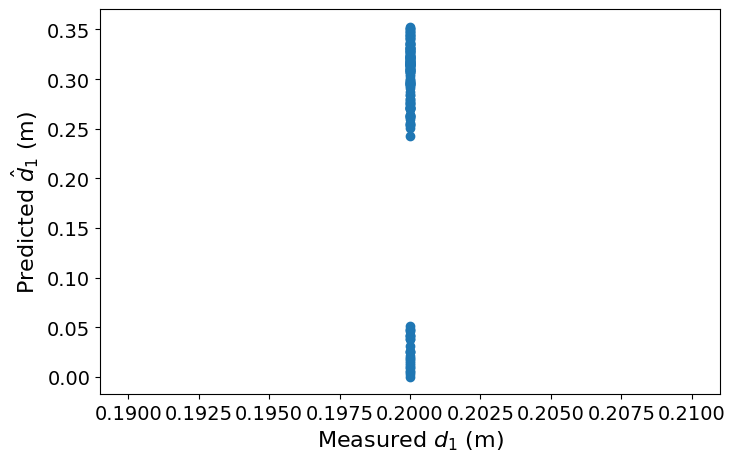

In [30]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,2],ExpTest_Pred[:,2])
plt.xlabel('Measured $d_1$ (m)',fontsize=16)
plt.ylabel('Predicted $\hat{d}_1$ (m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [31]:
specimen_1_pred_mean_p1 = np.mean(ExpTest_Pred[0:25,0])
specimen_2_pred_mean_p1 = np.mean(ExpTest_Pred[25:50,0])
specimen_3_pred_mean_p1 = np.mean(ExpTest_Pred[50:75,0])
specimen_4_pred_mean_p1 = np.mean(ExpTest_Pred[75:100,0])
specimen_5_pred_mean_p1 = np.mean(ExpTest_Pred[100:125,0])
specimen_6_pred_mean_p1 = np.mean(ExpTest_Pred[125:150,0])
ExpTest_Pred_Pro_p1 = np.array([specimen_1_pred_mean_p1,specimen_2_pred_mean_p1,specimen_3_pred_mean_p1,
                                    specimen_4_pred_mean_p1,specimen_5_pred_mean_p1,specimen_6_pred_mean_p1])
ExpTest_Label_Pro_p1 = np.array([ExpTest_Label[0,0],ExpTest_Label[25,0],ExpTest_Label[50,0],
                                    ExpTest_Label[75,0],ExpTest_Label[100,0],ExpTest_Label[125,0]])

In [32]:
# R^2
ExpTest_R2_p1 = r2_score(ExpTest_Label_Pro_p1,ExpTest_Pred_Pro_p1)
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred_Pro_p1 - ExpTest_Label_Pro_p1) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_Label_Pro_p1,ExpTest_Pred_Pro_p1)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred_Pro_p1) - np.mean(ExpTest_Label_Pro_p1)
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

p1 R2 on experimental tesing dataset: -5.4804279251
p1 MSE on experimental tesing dataset: 67.9670881024
p1 R on experimental tesing dataset: -0.2779149625
p1 Bias on experimental tesing dataset: -6.6331331110


p1 R on experimental tesing dataset: -0.2779149625
p1 Bias on experimental tesing dataset: -6.6331331110
p1 MSE on experimental tesing dataset: 67.9670881024
p1 RMSE on experimental tesing dataset: 8.2442154328
p1 ubMSE on experimental tesing dataset: 4.8957770817


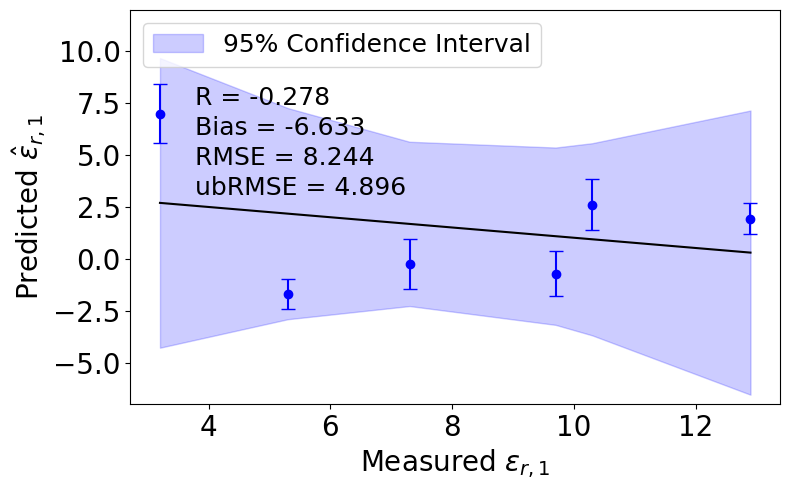

In [33]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:25,0])
mean_2 = np.mean(ExpTest_Pred[25:50,0])
mean_3 = np.mean(ExpTest_Pred[50:75,0])
mean_4 = np.mean(ExpTest_Pred[75:100,0])
mean_5 = np.mean(ExpTest_Pred[100:125,0])
mean_6 = np.mean(ExpTest_Pred[125:150,0])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:25,0])
std_2 = np.std(ExpTest_Pred[25:50,0])
std_3 = np.std(ExpTest_Pred[50:75,0])
std_4 = np.std(ExpTest_Pred[75:100,0])
std_5 = np.std(ExpTest_Pred[100:125,0])
std_6 = np.std(ExpTest_Pred[125:150,0])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,0],ExpTest_Label[25,0],ExpTest_Label[50,0],ExpTest_Label[75,0],ExpTest_Label[100,0],ExpTest_Label[125,0]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('p1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('p1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('p1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='blue', alpha=0.2, label='95% Confidence Interval')

# Plotting the Prediction Interval (PI)
# plt.fill_between(label, pi_lower, pi_upper, color='blue', alpha=0.2, label='95% Prediction Interval')

plt.xlabel(r'Measured $\varepsilon_{r,1}$',fontsize=20)
plt.ylabel(r'Predicted $\hat{\varepsilon}_{r,1}$', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.25, 0.78, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.25, 0.72, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.25, 0.66, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.25, 0.60, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-7,12])
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Permittivity_DANN_AllSamples_Notation', dpi=600)

In [34]:
specimen_1_pred_mean_c1 = np.mean(ExpTest_Pred[0:25,1])
specimen_2_pred_mean_c1 = np.mean(ExpTest_Pred[25:50,1])
specimen_3_pred_mean_c1 = np.mean(ExpTest_Pred[50:75,1])
specimen_4_pred_mean_c1 = np.mean(ExpTest_Pred[75:100,1])
specimen_5_pred_mean_c1 = np.mean(ExpTest_Pred[100:125,1])
specimen_6_pred_mean_c1 = np.mean(ExpTest_Pred[125:150,1])
ExpTest_Pred_Pro_c1 = np.array([specimen_1_pred_mean_c1,specimen_2_pred_mean_c1,specimen_3_pred_mean_c1,
                                    specimen_4_pred_mean_c1,specimen_5_pred_mean_c1,specimen_6_pred_mean_c1])
ExpTest_Label_Pro_c1 = np.array([ExpTest_Label[0,1],ExpTest_Label[25,1],ExpTest_Label[50,1],
                                    ExpTest_Label[75,1],ExpTest_Label[100,1],ExpTest_Label[125,1]])

In [35]:
# R^2
ExpTest_R2_c1 = r2_score(ExpTest_Label_Pro_c1,ExpTest_Pred_Pro_c1)
print('c1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c1))

# Mean square error
ExpTest_MSE_c1 = np.mean((ExpTest_Pred_Pro_c1 - ExpTest_Label_Pro_c1) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c1))

# R
ExpTest_R_c1 = np.corrcoef(ExpTest_Label_Pro_c1,ExpTest_Pred_Pro_c1)[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (ExpTest_R_c1))

# Bias
ExpTest_Bias_c1 = np.mean(ExpTest_Pred_Pro_c1) - np.mean(ExpTest_Label_Pro_c1)
print('c1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c1))

c1 R2 on experimental tesing dataset: -8.3919034811
c1 MSE on experimental tesing dataset: 0.0032277285
c1 R on experimental tesing dataset: -0.1127702407
c1 Bias on experimental tesing dataset: -0.0520642726


c1 R on experimental tesing dataset: -0.1127702407
c1 Bias on experimental tesing dataset: -0.0520642726
c1 MSE on experimental tesing dataset: 0.0032277285
c1 RMSE on experimental tesing dataset: 0.0568131016
c1 ubMSE on experimental tesing dataset: 0.0227385144


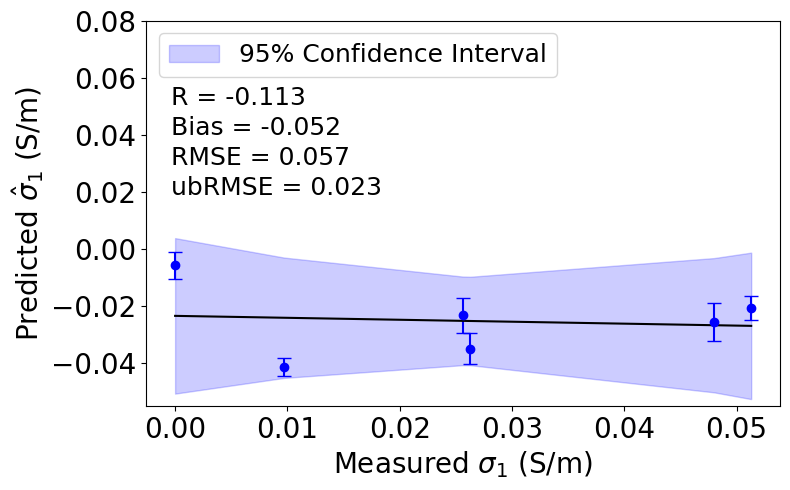

In [36]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:25,1])
mean_2 = np.mean(ExpTest_Pred[25:50,1])
mean_3 = np.mean(ExpTest_Pred[50:75,1])
mean_4 = np.mean(ExpTest_Pred[75:100,1])
mean_5 = np.mean(ExpTest_Pred[100:125,1])
mean_6 = np.mean(ExpTest_Pred[125:150,1])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:25,1])
std_2 = np.std(ExpTest_Pred[25:50,1])
std_3 = np.std(ExpTest_Pred[50:75,1])
std_4 = np.std(ExpTest_Pred[75:100,1])
std_5 = np.std(ExpTest_Pred[100:125,1])
std_6 = np.std(ExpTest_Pred[125:150,1])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,1],ExpTest_Label[25,1],ExpTest_Label[50,1],ExpTest_Label[75,1],ExpTest_Label[100,1],ExpTest_Label[125,1]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('c1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('c1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('c1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='blue', alpha=0.2, label='95% Confidence Interval')

# Plotting the Prediction Interval (PI)
# plt.fill_between(label, pi_lower, pi_upper, color='blue', alpha=0.2, label='95% Prediction Interval')

plt.xlabel(r'Measured $\sigma_1$ (S/m)',fontsize=20)
plt.ylabel(r'Predicted $\hat{\sigma}_1$ (S/m)', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.22, 0.78, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.22, 0.72, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.22, 0.66, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.22, 0.60, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-0.055,0.08])
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Conductivity_DANN_AllSamples_Notation', dpi=600)

In [37]:
specimen_1_pred_mean_d1 = np.mean(ExpTest_Pred[0:25,2])
specimen_2_pred_mean_d1 = np.mean(ExpTest_Pred[25:50,2])
specimen_3_pred_mean_d1 = np.mean(ExpTest_Pred[50:75,2])
specimen_4_pred_mean_d1 = np.mean(ExpTest_Pred[75:100,2])
specimen_5_pred_mean_d1 = np.mean(ExpTest_Pred[100:125,2])
specimen_6_pred_mean_d1 = np.mean(ExpTest_Pred[125:150,2])
ExpTest_Pred_Pro_d1 = np.array([specimen_1_pred_mean_d1,specimen_2_pred_mean_d1,specimen_3_pred_mean_d1,
                                    specimen_4_pred_mean_d1,specimen_5_pred_mean_d1,specimen_6_pred_mean_d1])
ExpTest_Label_Pro_d1 = np.array([ExpTest_Label[0,2],ExpTest_Label[25,2],ExpTest_Label[50,2],
                                    ExpTest_Label[75,2],ExpTest_Label[100,2],ExpTest_Label[125,2]])

In [38]:
# R^2
ExpTest_R2_d1 = r2_score(ExpTest_Label_Pro_d1,ExpTest_Pred_Pro_d1)
print('d1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_d1))

# Mean square error
ExpTest_MSE_d1 = np.mean((ExpTest_Pred_Pro_d1 - ExpTest_Label_Pro_d1) ** 2)
print('d1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_d1))

# R
ExpTest_R_d1 = np.corrcoef(ExpTest_Label_Pro_d1,ExpTest_Pred_Pro_d1)[0,1]
print('d1 R on experimental tesing dataset: %.10f' % (ExpTest_R_d1))

# Bias
ExpTest_Bias_d1 = np.mean(ExpTest_Pred_Pro_d1) - np.mean(ExpTest_Label_Pro_d1)
print('d1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_d1))

# RMSE
ExpTest_RMSE_d1 = np.sqrt(ExpTest_MSE_d1)
print('d1 RMSE on experimental tesing dataset: %.10f' % (ExpTest_RMSE_d1))

# ubRMSE
ExpTest_ubRMSE_d1 = np.sqrt((ExpTest_RMSE_d1 ** 2 - ExpTest_Bias_d1 ** 2))
print('d1 ubRMSE on experimental tesing dataset: %.10f' % (ExpTest_ubRMSE_d1))

d1 R2 on experimental tesing dataset: -19852791053843016254206483890176.0000000000
d1 MSE on experimental tesing dataset: 0.0152940339
d1 R on experimental tesing dataset: 0.0000000000
d1 Bias on experimental tesing dataset: 0.0610830577
d1 RMSE on experimental tesing dataset: 0.1236690499
d1 ubRMSE on experimental tesing dataset: 0.1075308978


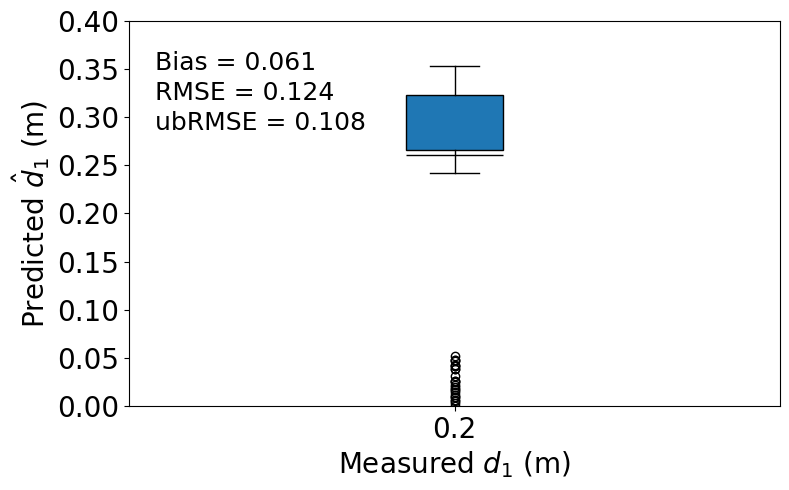

In [39]:
# Box plot
fig = plt.figure(figsize=(8, 5))
box = plt.boxplot(ExpTest_Pred[:,2],patch_artist=True,meanline=True,showmeans=True)
colors = ['#1f77b4']
# fill with colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
for mean in box['means']:
    mean.set_color('black')
    mean.set_linestyle('solid')
for median in box['medians']:
    median.set_linewidth(0)

plt.xlabel('Measured $d_1$ (m)',fontsize=20)
plt.ylabel('Predicted $\hat{d}_1$ (m)',fontsize=20)
labels = ['0.2']
plt.xticks([1], labels, fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.ylim([0,0.4])
plt.figtext(0.2, 0.85, f'Bias = %.3f' % ExpTest_Bias_d1, fontsize=18)
plt.figtext(0.2, 0.79, f'RMSE = %.3f' % ExpTest_RMSE_d1, fontsize=18)
plt.figtext(0.2, 0.73, f'ubRMSE = %.3f' % ExpTest_ubRMSE_d1, fontsize=18)
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Depth_DANN_AllSamples', dpi=600)

In [40]:
np.std(ExpTest_Pred[:,2])

0.10839578871460769